# Perturbation anatomy: what the transforms actually do to a spectrum

Every other notebook in this campaign reduces a perturbation to a single number, an angle
in the latent space. This one stays at the level of the spectrum. It shows what each
transform does to real data, whether the result still lives on the original spectrum's
support, and how large the resulting change is considered to be under each candidate input
metric.

No trained model appears here. The transforms and their lengths are properties of the data
and of the metric, so this is the part of the analysis that is true regardless of which
encoder is eventually chosen. `part_6` takes the same transforms to two trained models and
compares their reconstructions.

## Introduction

Two questions are answered, both prerequisites for reading any of the model-level results.

1. **What the transform does, and whether it stays on the spectrum's support.** A one-bin
   m/z shift and a peak broadening are described in one line each, but their effect on a
   sparse, peak-like spectrum is not obvious, and whether they preserve the support turns
   out to decide whether the trained geometry can see them at all.
2. **How large the change is.** The same perturbation has very different lengths under the
   Euclidean, Cramér, Gaussian and Fisher-Rao metrics. Since the campaign's central decision
   was to change that metric, seeing the disagreement directly is more informative than
   reading it off a correlation.

### Assumptions

- **A model configuration is loaded only to resolve the dataset.** The wrapper needs a saved
  configuration to establish the reader, binner and split; no encoder or decoder is
  evaluated in this notebook.
- **One spectrum is shown, many are measured.** The figures follow a small number of fixed,
  deterministically chosen spectra so the reader can track the same object across every
  panel. Every distribution and summary uses the full pixel sample, and the displayed
  spectra are identified by index so they can be recovered.
- **The Fisher-Rao length of a perturbation can be undefined.** Its definition,
  $\lVert\delta\rVert_F^2=\sum_m \delta_m^2/x_m$, has an infinite term wherever the
  perturbation puts mass into a bin the original spectrum left empty. The value reported
  here is computed over the support only, and is accompanied by the share of the
  perturbation's squared length that this truncation discards. A large share means the
  number is not a length but a lower bound on an infinite quantity.
### Notation

For a spectrum $x$ on the simplex and transform $T$, write $\delta = T(x)-x$ after TIC
renormalization. The metrics compared are the Euclidean length $\lVert\delta\rVert_2$, the
Cramér length $\lVert C\delta\rVert_2$ with $C$ the cumulative sum along m/z, the Gaussian
length $\lVert K_\sigma\delta\rVert_2$, and the Fisher-Rao length
$\big(\sum_m \delta_m^2/x_m\big)^{1/2}$.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import contractive_precompute as precompute
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import sweep_evaluation as evaluation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import perturbations as perturbation
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("perturbation_anatomy")

2026-09-09 17:23:18,069 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-09 17:23:18,072 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


## Configuration and spectra

## Producing the tables this notebook reads

### Methodology

#### Implementation

No trained model is evaluated here, but a saved configuration must be loaded to resolve the dataset, and the spectra the figures draw have to be produced and stored: a spectrum cannot be redrawn from summary statistics.

That work lives in `contractive_precompute.perturbation_anatomy`, is configured by
`analysis_settings.yaml` next to this notebook, and writes its tables to this notebook's
results directory. The m/z grid comes from the binner itself rather than from an assumed step, so the Cramer length is measured on the axis the data actually uses.

Run it once, detached, with the command printed below. It refuses to start on the
processor unless explicitly allowed, since a processor-only build of the tensor library
turns minutes into hours without saying so. The command is generated by the runner
itself, so the instruction cannot drift from the entry point it describes.

Everything after this section reads those tables, which is why re-running this notebook
takes seconds.

### Remarks

### Notes

In [2]:
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/analysis_settings.yaml")
ANALYSIS = "perturbation_anatomy"

settings = precompute.read_settings(SETTINGS_PATH)
analysis_settings = precompute.analysis_settings(settings, ANALYSIS)
ARTIFACT_DIR = analysis_settings["output_directory"]

# Seeds and sample settings come from the settings file, so the notebook and the
# precompute cannot drift apart on them.
SAMPLE_SEED = int(settings["sample_seed"])
PERTURBATION_SETTINGS = perturbation.PerturbationSettings(**analysis_settings["perturbation"])

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
# Inline figures are stored inside the notebook as PNG. Rendering them at 100
# dpi instead of the theme's 140 roughly halves the stored size, leaving figure
# geometry and font proportions untouched, so the notebook stays openable in
# viewers that fall back to the text output on very large images.
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

print("Run the precompute once, in the background:")
print(f"  {precompute.run_command(settings, ANALYSIS)}")
print("\nOr in the foreground, to watch it:")
print(f"  {precompute.run_command(settings, ANALYSIS, background=False)}")

Run the precompute once, in the background:
  nohup python -m msi_autoencoder_wrapper.analysis.autoencoder.experiments.contractive_precompute --settings assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/analysis_settings.yaml --analysis perturbation_anatomy > assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_0_3_perturbation_anatomy_results/perturbation_anatomy.log 2>&1 &

Or in the foreground, to watch it:
  python -m msi_autoencoder_wrapper.analysis.autoencoder.experiments.contractive_precompute --settings assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/analysis_settings.yaml --analysis perturbation_anatomy


In [3]:
# Tables produced by the command above; `load_table` reports the command again
# if one is missing, so a fresh checkout fails with an instruction rather than
# a stack trace.
norm_frame = precompute.load_table(settings, ANALYSIS, "perturbation_norms")
diagnostics_frame = precompute.load_table(settings, ANALYSIS, "perturbation_diagnostics")
spectra_frame = precompute.load_table(settings, ANALYSIS, "displayed_spectra")
grid_frame = precompute.load_table(settings, ANALYSIS, "grid")

provenance = precompute.load_metadata(settings, ANALYSIS)

# The spectra the figures draw, keyed by the row each case was selected as.
shown_rows = provenance["displayed_rows"]
mass_axis = spectra_frame.query("row == @shown_rows[0] and series == 'clean'")["mz"].to_numpy()
series_by_row = {
    (int(row), series): group["intensity"].to_numpy()
    for (row, series), group in spectra_frame.groupby(["row", "series"])
}
off_support_samples = {
    name: group["off_support_fraction"].to_numpy()
    for name, group in norm_frame.groupby("perturbation")
}
PERTURBATION_COLOR = {
    name: theme.color_for_model(name, index)
    for index, name in enumerate(perturbation.PERTURBATION_NAMES)
}
focus_row = int(shown_rows[0])
print(f"{provenance['analysed_spectra']} spectra analysed; showing rows {shown_rows}")
print(f"precomputed at commit {provenance['git_commit']} on {provenance['device']}")

2000 spectra analysed; showing rows [396, 226, 407]
precomputed at commit d52fbf0d49fd31716ead9d97121b2ab7a23147c9 on cuda


## What each transform does to a spectrum

### Methodology

#### Theoretical

The four transforms are one-line descriptions with very different consequences for a
sparse, peak-like spectrum. A discrete m/z shift moves every peak into a neighbouring bin,
which for peaks about one bin wide means the perturbed spectrum has almost no overlap with
the original: the change is not a small deformation of each peak but a wholesale relocation.
Broadening keeps peaks where they are and redistributes their mass locally. The two noise
families leave the peak positions untouched and only alter amplitudes, multiplicatively or
additively.

Seeing this is what makes the later numbers interpretable, since the same angular
displacement means something different depending on whether the input change preserved the
spectrum's structure or replaced it.

#### Implementation

Each family is applied through `perturb_spectra` at full strength to the shared spectrum
sample, with a seeded generator for the stochastic pair. The displayed window is the
m/z region containing the most detected peaks for the displayed spectrum, so the figure
shows resolved structure rather than an unreadable full-range trace.

#### Figure descriptions

One row per transform, named on the left. The left column shows the original spectrum in
grey and the perturbed spectrum in color over a zoomed m/z window, both as intensity against
m/z, with vertical extent shared within a row. The right column shows the perturbation
$\delta$ itself over the same window, on its own symmetric scale, with a horizontal line at
zero; positive values are mass gained by a bin and negative values mass lost. A transform
whose $\delta$ alternates sign between adjacent bins is relocating mass, while one whose
$\delta$ is small and spread out is reshaping it.

### Remarks

### Notes

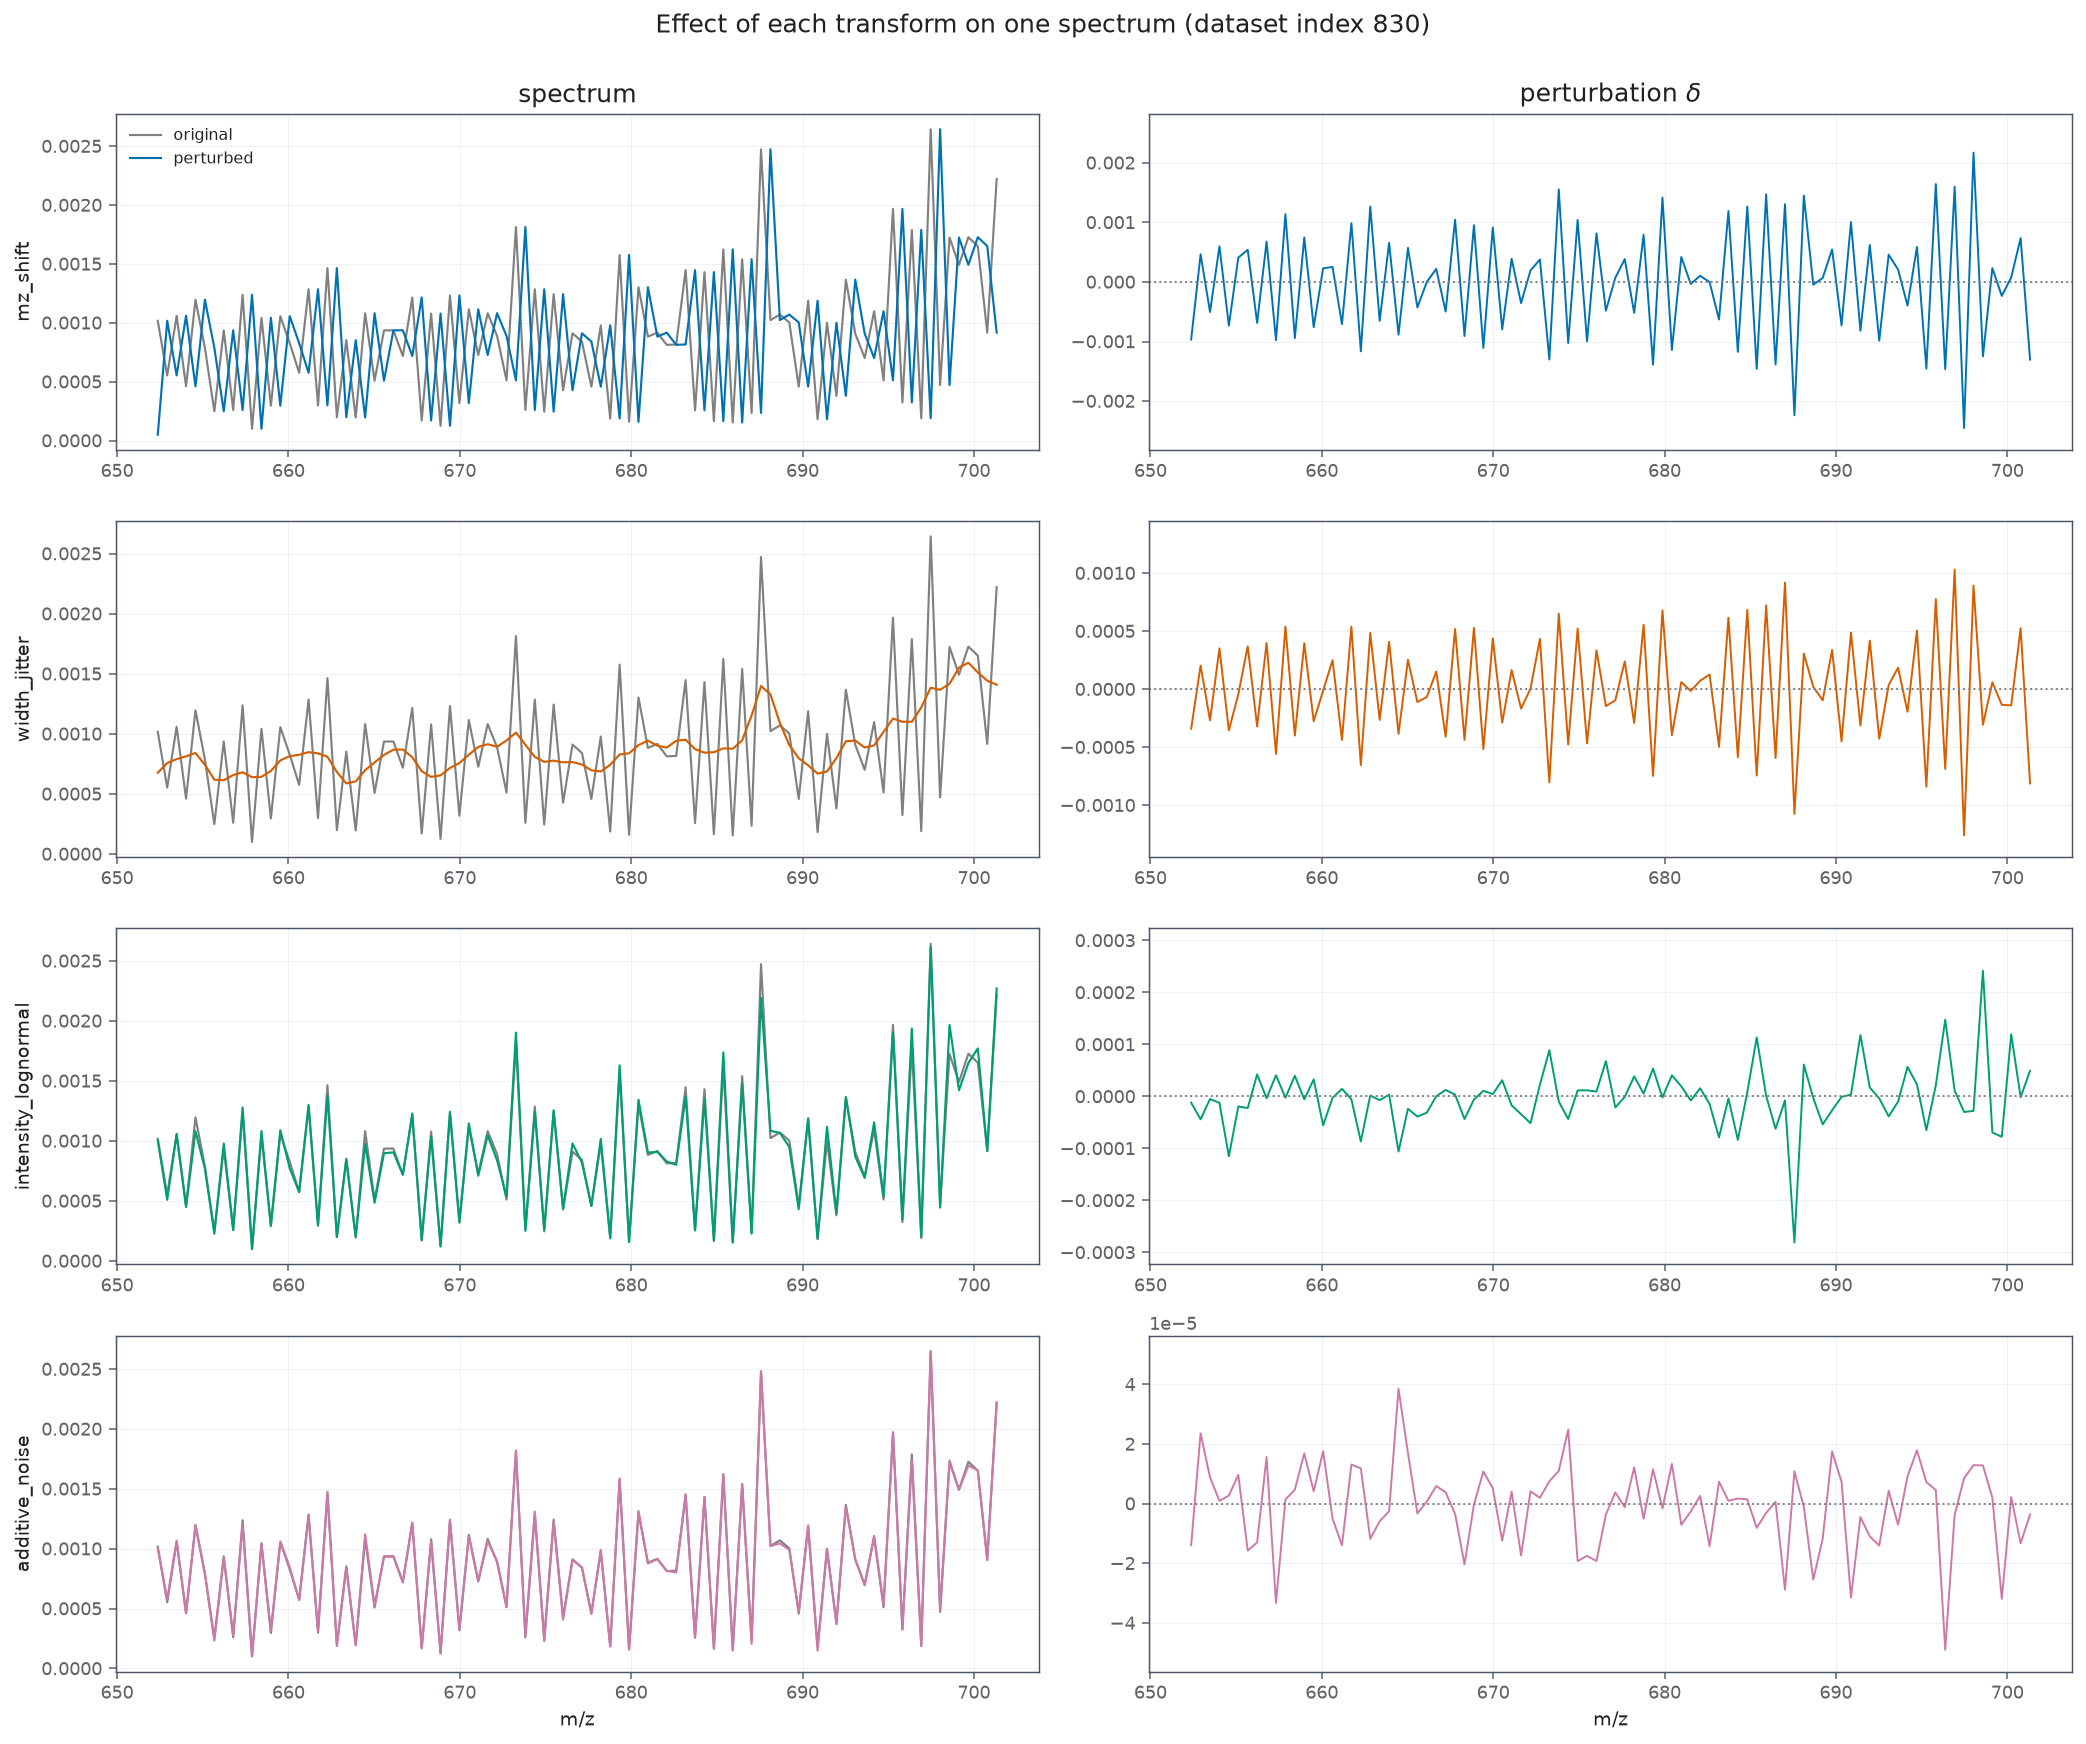

In [4]:
# --- what this figure shows ------------------------------------------------
WINDOW_BINS = 90          # width of the zoom window, in bins
# ---------------------------------------------------------------------------
def zoom_window(spectrum: np.ndarray, width: int = WINDOW_BINS) -> slice:
    """Window of `width` bins centred on the densest peak region of one spectrum."""
    dense = np.convolve((spectrum > spectrum.mean()).astype(float), np.ones(width), mode="same")
    centre = int(np.argmax(dense))
    start = max(0, min(centre - width // 2, len(spectrum) - width))
    return slice(start, start + width)


focus_clean = series_by_row[(focus_row, "clean")]
window = zoom_window(focus_clean)

figure, axes = plt.subplots(len(perturbation.PERTURBATION_NAMES), 2,
                            figsize=(15.0, 3.1 * len(perturbation.PERTURBATION_NAMES)), dpi=theme.figure_dpi)
for row, name in enumerate(perturbation.PERTURBATION_NAMES):
    perturbed = series_by_row[(focus_row, name)]
    delta = perturbed - focus_clean
    spectrum_axis, delta_axis = axes[row]
    spectrum_axis.plot(mass_axis[window], focus_clean[window], color="grey", linewidth=1.1, label="original")
    spectrum_axis.plot(mass_axis[window], perturbed[window], color=PERTURBATION_COLOR[name], linewidth=1.1, label="perturbed")
    spectrum_axis.set(ylabel=name, xlabel="m/z" if row == len(perturbation.PERTURBATION_NAMES) - 1 else "")
    spectrum_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    if row == 0:
        spectrum_axis.legend(fontsize=8, frameon=theme.legend_frame)
        spectrum_axis.set_title("spectrum")
    limit = float(np.abs(delta[window]).max()) or 1.0
    delta_axis.plot(mass_axis[window], delta[window], color=PERTURBATION_COLOR[name], linewidth=1.0)
    delta_axis.axhline(0.0, color="grey", linestyle=":", linewidth=1)
    delta_axis.set_ylim(-1.15 * limit, 1.15 * limit)
    delta_axis.set(xlabel="m/z" if row == len(perturbation.PERTURBATION_NAMES) - 1 else "")
    delta_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    if row == 0:
        delta_axis.set_title(r"perturbation $\delta$")
figure.suptitle(f"Effect of each transform on one spectrum (dataset index {provenance['displayed_dataset_indices'][0]})", y=1.001, fontsize=13)
figure.tight_layout()

## Does the perturbation stay on the spectrum's support?

### Methodology

#### Theoretical

This is the decisive structural property and it separates the transforms sharply. A
perturbation that only changes intensities in bins that already carry signal stays on the
spectrum's support. One that puts mass into previously empty bins leaves it, and no
support-respecting local geometry, the Fisher-Rao metric included, assigns it a finite
length. Since the campaign's penalty is built on exactly that geometry, a transform which
mostly leaves the support is one the penalty cannot bound even in principle.

Three quantities describe this: the mass introduced into originally empty bins, the mass
pushed off the ends of the m/z grid, and the share of the perturbation's squared Euclidean
length that lies off support.

#### Implementation

`perturb_spectra` returns the first two per spectrum, and `perturbation_norms` the third.
All are computed on the full spectrum sample, not only on the displayed spectra.

#### Figure descriptions

The table lists per transform the mean and maximum of the introduced mass, the boundary
mass lost and the input displacement. The figure shows, per transform, the distribution
across spectra of the share of squared perturbation length lying off the original support:
the x-axis lists transforms, the y-axis is that share between zero and one, each violin uses
every spectrum and the overlaid points are a fixed subsample. A share near zero means the
perturbation is a reshaping the trained geometry can see; a share near one means it is
effectively a different spectrum.

### Remarks

### Notes

,perturbation,deterministic,mean_boundary_mass_lost,max_boundary_mass_lost,mean_introduced_mass,max_introduced_mass,mean_input_displacement,max_input_displacement
0,mz_shift,True,0.00007,0.00181,0.46675,1.00000,0.17377,0.77377
1,width_jitter,True,0.00019,0.00281,0.25743,0.62395,0.08827,0.39545
2,intensity_lognormal,False,0.00000,0.00000,0.00000,0.00000,0.00592,0.02627
3,additive_noise,False,0.00000,0.00000,0.00390,0.00832,0.00093,0.00373


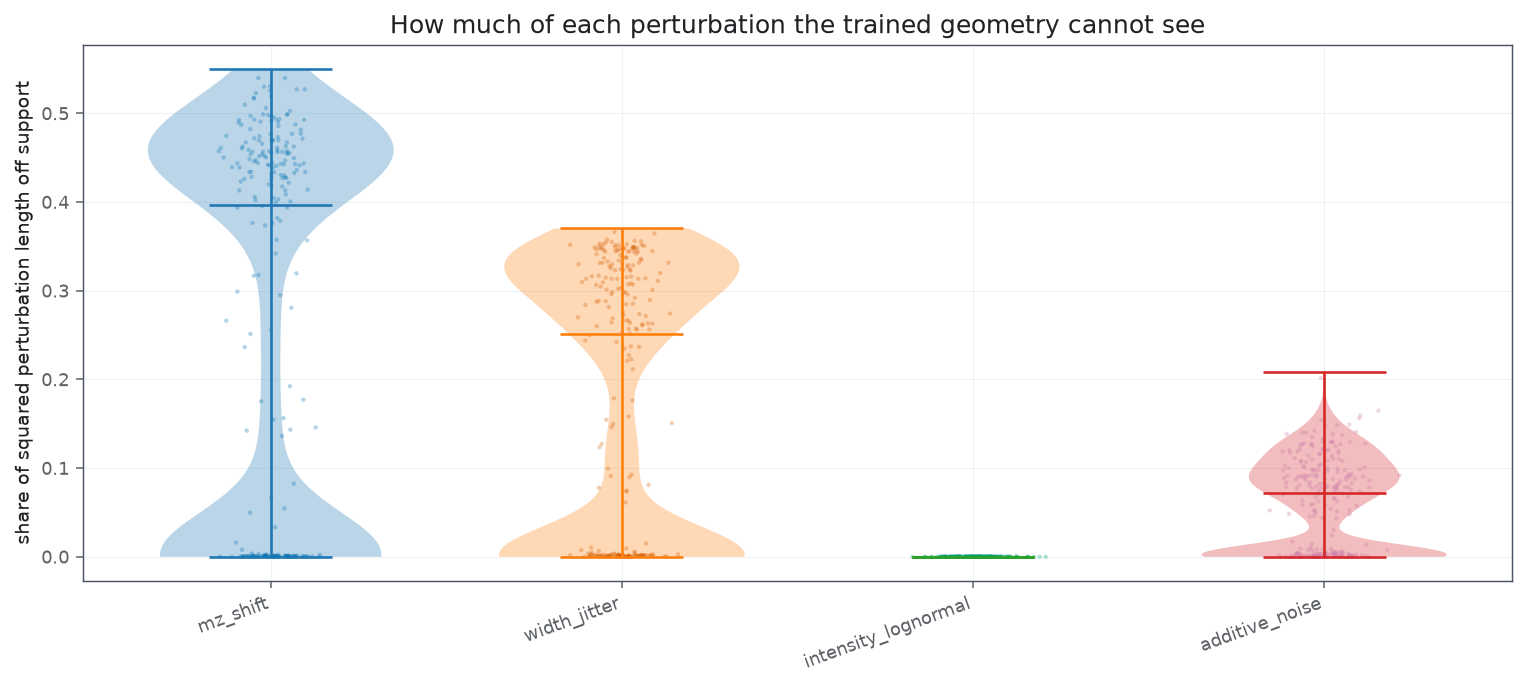

In [5]:
# --- what this figure shows ------------------------------------------------
POINT_SAMPLE = 250        # points overlaid per violin; the violin uses every spectrum
# ---------------------------------------------------------------------------
display(diagnostics_frame.round(5))

point_rng = np.random.default_rng(SAMPLE_SEED + 5)
figure, ax = plt.subplots(figsize=(11.0, 5.0), dpi=theme.figure_dpi)
for position, name in enumerate(perturbation.PERTURBATION_NAMES):
    values = off_support_samples[name]
    ax.violinplot([values], positions=[position], widths=0.7, showmedians=True)
    shown = point_rng.choice(values, min(POINT_SAMPLE, len(values)), replace=False)
    ax.scatter(position + point_rng.normal(0.0, 0.06, size=len(shown)), shown,
               color=PERTURBATION_COLOR[name], s=5, alpha=0.3, edgecolor="none")
ax.set_xticks(range(len(perturbation.PERTURBATION_NAMES)))
ax.set_xticklabels(perturbation.PERTURBATION_NAMES, rotation=20, ha="right")
ax.set(ylabel="share of squared perturbation length off support",
       title="How much of each perturbation the trained geometry cannot see")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## How large is the change, according to each metric?

### Methodology

#### Theoretical

The campaign's central decision was to change the input metric from Euclidean to
Fisher-Rao. That decision is only meaningful if the metrics actually disagree about how
large a given change is. Here the same perturbations are measured under four candidate
metrics: the Euclidean length, the Cramér length, which accumulates displacement along the
mass axis and therefore grows with a shift, the Gaussian length, which keeps only what
survives smoothing at instrument resolution, and the Fisher-Rao length, which weights a
change by the inverse of the intensity already present.

The Fisher-Rao column has to be read with the previous section in hand. Where a
perturbation leaves the support, its Fisher length is infinite, and the number reported is
the on-support part only. For such a transform the column is a lower bound rather than a
measurement, and the ranking it induces is not trustworthy.

#### Implementation

`perturbation_norms` computes all four primal lengths per spectrum. These are lengths of
the perturbation itself and are distinct from the dual operator norms
`sensitivity.metric_operators` builds from a Jacobian, which describe a model rather than a
change.

#### Figure descriptions

The first table reports the median length of each transform under each metric, so rows can
be compared within a column. The figure shows one panel per metric: the x-axis lists the
transforms, the y-axis the length on a logarithmic scale, each violin covering every
spectrum with a fixed subsample of points overlaid. The panels are what makes the metrics'
disagreement visible: a transform that ranks first under one metric and last under another
is exactly the case that motivated changing the metric.

### Remarks

### Notes

,euclidean,cramer,gaussian,fisher_rao
perturbation,,,,
mz_shift,0.19333,0.07981,0.16098,1.81162
width_jitter,0.09840,0.03291,0.08173,0.97272
intensity_lognormal,0.00557,0.03307,0.00500,0.04919
additive_noise,0.00098,0.01913,0.00088,0.01014


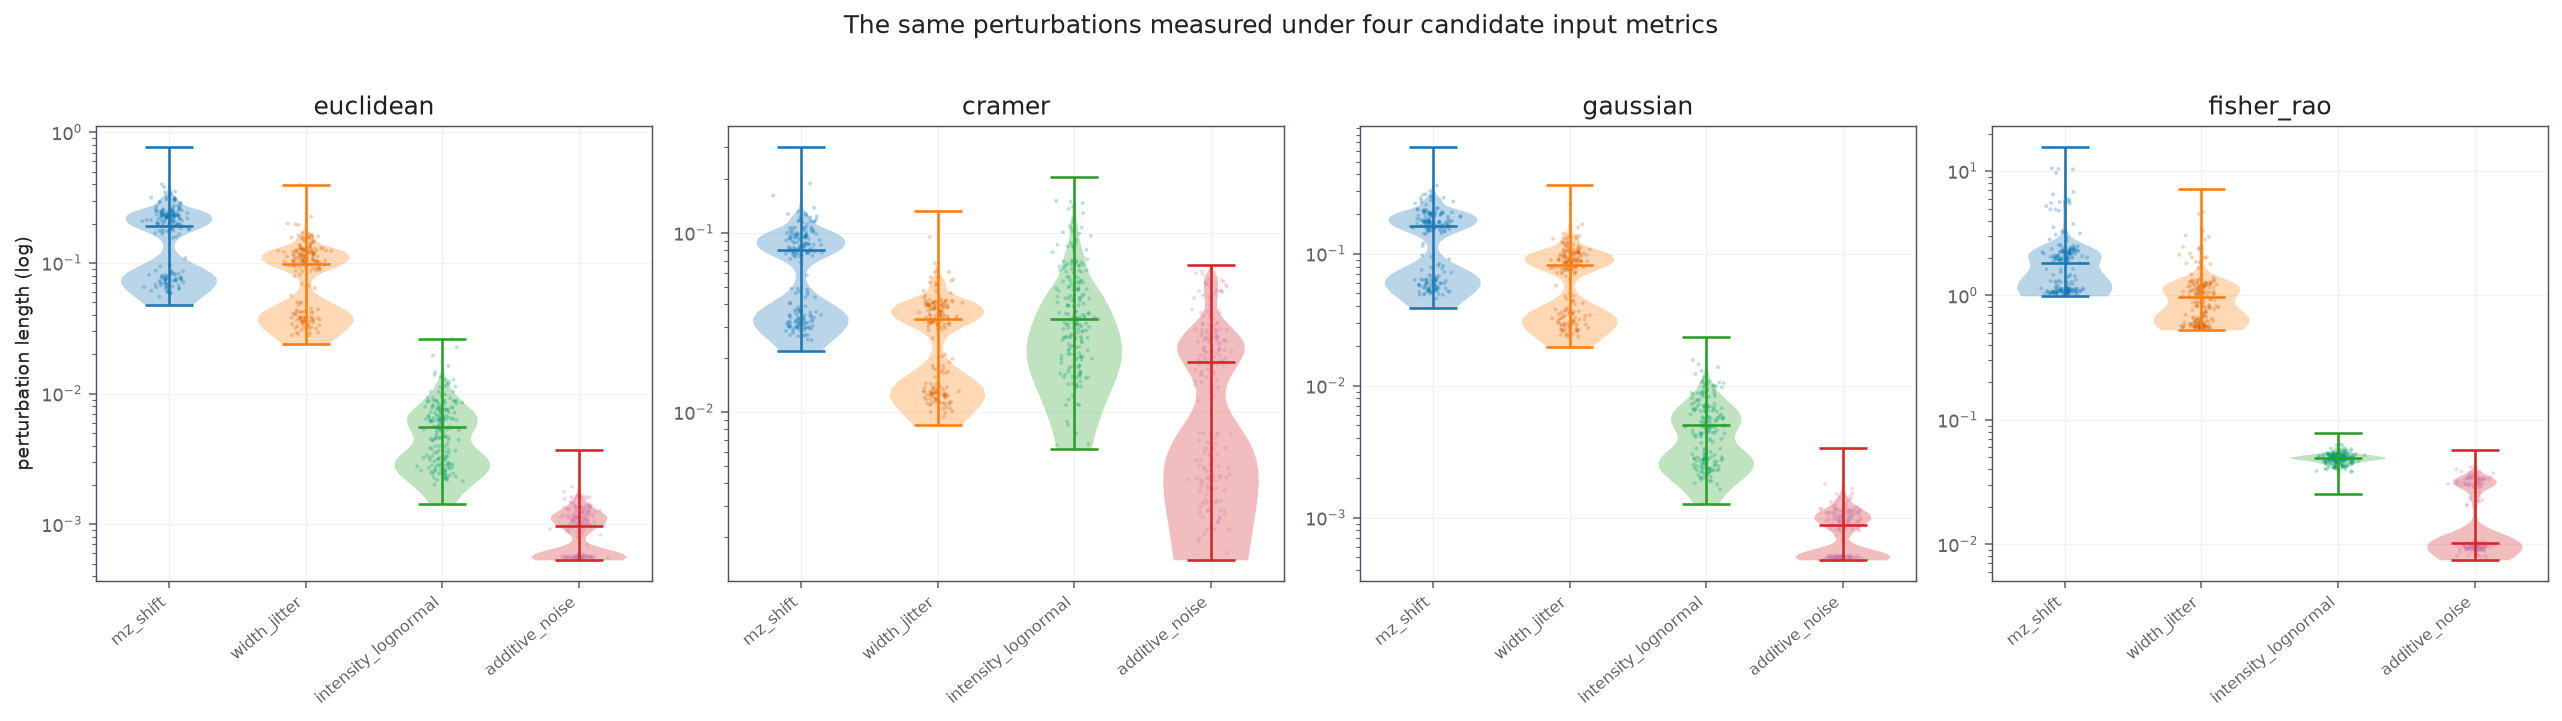

In [6]:
METRIC_COLUMNS = ["euclidean", "cramer", "gaussian", "fisher_rao"]
display(
    norm_frame.pivot_table(index="perturbation", columns=None, values=METRIC_COLUMNS, aggfunc="median")
    .reindex(perturbation.PERTURBATION_NAMES)[METRIC_COLUMNS].round(5)
)

figure, axes = plt.subplots(1, len(METRIC_COLUMNS), figsize=(4.6 * len(METRIC_COLUMNS), 5.0), dpi=theme.figure_dpi)
for axis, metric in zip(axes, METRIC_COLUMNS):
    for position, name in enumerate(perturbation.PERTURBATION_NAMES):
        values = norm_frame.query("perturbation == @name")[metric].to_numpy()
        values = values[values > 0]
        if not len(values):
            continue
        axis.violinplot([values], positions=[position], widths=0.7, showmedians=True)
        shown = point_rng.choice(values, min(200, len(values)), replace=False)
        axis.scatter(position + point_rng.normal(0.0, 0.06, size=len(shown)), shown,
                     color=PERTURBATION_COLOR[name], s=4, alpha=0.28, edgecolor="none")
    axis.set_yscale("log")
    axis.set_xticks(range(len(perturbation.PERTURBATION_NAMES)))
    axis.set_xticklabels(perturbation.PERTURBATION_NAMES, rotation=40, ha="right", fontsize=8)
    axis.set(ylabel="perturbation length (log)" if metric == METRIC_COLUMNS[0] else "", title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle("The same perturbations measured under four candidate input metrics", y=1.02, fontsize=13)
figure.tight_layout()

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the precompute runner, not here.
This notebook adds only no derived tables of its own, which are a few operations on tables already in
memory. Provenance for the measured part, including the commit, the device, the seeds and
the source hashes of the analysis modules, lives in the runner's `metadata.json`.

The results directory is deliberately not versioned: it is regenerable from the runner
and its recorded provenance, and the tables are large.

### Remarks

### Notes

In [7]:
# Every table here is produced by the precompute runner, which also wrote the provenance.
print("precomputed tables present:", sorted(path.name for path in ARTIFACT_DIR.glob("*.csv")))
print("provenance:", {key: provenance[key] for key in ("analysis", "git_commit", "device", "analysed_spectra")})

precomputed tables present: ['analysed_spectra.csv', 'displayed_spectra.csv', 'grid.csv', 'perturbation_diagnostics.csv', 'perturbation_norms.csv']
provenance: {'analysis': 'perturbation_anatomy', 'git_commit': 'd52fbf0d49fd31716ead9d97121b2ab7a23147c9', 'device': 'cuda', 'analysed_spectra': 2000}


## Results / Summary

### LLM

**The m/z shift is largely not a perturbation of the spectrum but a replacement of it.**
For the median spectrum, 39.7% of the shift's squared length lies in bins the original left
empty, rising to 55% in the worst case. Peak broadening reaches 25.1%. This follows from the
binning: `part_0` measured a median peak width of one bin, so displacing by one bin moves
each peak entirely into a neighbour rather than deforming it. The two intensity families
behave oppositely, with `intensity_lognormal` at exactly zero off support, as a multiplicative
change cannot create a peak where there was none, and `additive_noise` at 7.2%.

**Consequence for the campaign's central decision.** The Fisher-Rao length,
$\sum_m \delta_m^2/x_m$, has an infinite term wherever a perturbation puts mass into an empty
bin. For the m/z shift that condition holds for roughly 40% of the perturbation's length, so
the reported Fisher figure of 1.81 is not a length but a lower bound on an infinite quantity,
and the same applies to broadening at 0.97. The metric that the whole campaign adopted
therefore cannot assign a finite size to the perturbation the campaign was built around. This
does not invalidate the trained models, whose behaviour is measured empirically in `part_5`
and `part_6`, but it does mean that any argument of the form "Fisher-Rao rates the m/z shift
as large, therefore the penalty bounds it" is unsound.

**The metrics disagree enough for the choice to matter, and they reorder the families.**
Median lengths of the same four perturbations: Euclidean 0.193, 0.098, 0.0056 and 0.00098
for shift, broadening, intensity and additive noise respectively; Cramér 0.080, 0.033, 0.033
and 0.019. Under the Euclidean metric intensity noise is eighteen times smaller than
broadening; under Cramér the two are indistinguishable, 0.0331 against 0.0329. A metric
choice is therefore not a matter of scale but of which perturbations count as comparable.

**The Gaussian metric is nearly a rescaled Euclidean one**, at 0.161 against 0.193 for the
shift and 0.082 against 0.098 for broadening, preserving the ordering throughout. This
reproduces `part_0`'s finding on a different quantity: at a one-bin peak width there is no
sub-peak structure for smoothing to remove, so the Gaussian metric adds nothing over the
Euclidean one at this binning.

**Reading guidance for the rest of the campaign.** Because the families differ in Euclidean
length by more than two orders of magnitude, from 0.193 down to 0.00098, no comparison of
response magnitudes between families is meaningful. Only within-family comparisons between
models are, which is how `part_5` and `part_6` are constructed.

### Person